In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

from log_energy_epjst_package.models.white_noise import white_noise
from log_energy_epjst_package.models.brownian_motion import brownian_motion
from MRW_LAMBDA_ESTIMATOR.surrogate_mrw_lambda import generate_mrw
from signal_analysis import analyze_signal
from toy_models.model5_lognormal_cascade import generate as generate_lognormal_cascade

def covariance_fft(x):
    x = x - np.mean(x)
    c = fftconvolve(x, x[::-1], mode='full')
    c = c[c.size//2:]
    return c / c[0]


def compare_signals(signals, **analysis_kwargs):
    results = {}
    for name, signal in signals.items():
        results[name] = analyze_signal(signal, **analysis_kwargs)
    return results


def plot_signals(results):
    """Plot the original signals (treated as log-price)."""
    fig, axes = plt.subplots(len(results), 1, figsize=(10, 4 * len(results)), sharex=True)
    if len(results) == 1:
        axes = [axes]

    for ax, (name, output) in zip(axes, results.items()):
        ax.plot(output["signal"])
        ax.set_title(f'{name}: Signal')
        ax.set_ylabel('Value')

    plt.xlabel('Time')
    plt.tight_layout()
    plt.show()


def plot_volatility_walks(results, scale_idx=3):
    """Plot centered log-volatility walks for each signal."""
    fig, axes = plt.subplots(len(results), 1, figsize=(10, 4 * len(results)), sharex=True)
    if len(results) == 1:
        axes = [axes]

    for ax, (name, output) in zip(axes, results.items()):
        w_a = output["log_vol_series"][scale_idx]
        w_a_centered = w_a - np.mean(w_a)
        v_a = np.cumsum(w_a_centered)
        ax.plot(v_a)
        ax.set_title(f'{name}: Centered Log-Volatility Walk (Scale {output["scales"][scale_idx]})')
        ax.set_ylabel('Walk Value')

    plt.xlabel('Time')
    plt.tight_layout()
    plt.show()


def plot_autocorrelations(results, scale_idx=3, max_lag=500):
    """Plot autocorrelations of returns and log-volatility."""
    fig, axes = plt.subplots(len(results), 2, figsize=(12, 4 * len(results)))
    if len(results) == 1:
        axes = axes.reshape(1, -1)

    for i, (name, output) in enumerate(results.items()):
        signal = output["signal"]
        ret = np.diff(signal)
        ret_ac = covariance_fft(ret)

        w_a = output["log_vol_series"][scale_idx]
        w_ac = covariance_fft(w_a)

        axes[i, 0].plot(ret_ac[:max_lag+1])
        axes[i, 0].set_title(f'{name}: Return Autocorrelation')
        axes[i, 0].set_xlabel('Lag')
        axes[i, 0].set_ylabel('Autocorrelation')

        axes[i, 1].plot(w_ac[:max_lag+1])
        axes[i, 1].set_title(f'{name}: Log-Volatility Autocorrelation (Scale {output["scales"][scale_idx]})')
        axes[i, 1].set_xlabel('Lag')
        axes[i, 1].set_ylabel('Autocorrelation')

    plt.tight_layout()
    plt.show()


def plot_mi_maps(results, max_time_lag):
    fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5), sharey=True)
    if len(results) == 1:
        axes = [axes]

    for ax, (name, output) in zip(axes, results.items()):
        im = ax.imshow(
            output["mi_map"],
            aspect="auto",
            origin="upper",
            cmap="hot",
            extent=[-max_time_lag, max_time_lag, output["scales"][-1], output["scales"][0]],
        )
        ax.set_title(name)
        ax.set_xlabel("Time lag")
        ax.set_ylabel("Scale")
        fig.colorbar(im, ax=ax, label="Mutual Information")

    plt.tight_layout()
    plt.show()


    for key in results.keys():
            mi_normalized = []
            for i,I in enumerate(results[key]["mi_map"]):
                mi_normalized.append(I/np.max(I))
            results[key]["mi_map_normalized"] = mi_normalized
    
    fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5), sharey=True)
    if len(results) == 1:
        axes = [axes]

    for ax, (name, output) in zip(axes, results.items()):
        im = ax.imshow(
            output["mi_map_normalized"],
            aspect="auto",
            origin="upper",
            cmap="hot",
            extent=[-max_time_lag, max_time_lag, output["scales"][-1], output["scales"][0]],
        )
        ax.set_title(name)
        ax.set_xlabel("Time lag")
        ax.set_ylabel("Scale")
        fig.colorbar(im, ax=ax, label="Mutual Information normalized")

    plt.tight_layout()
    plt.show()

white_noise: log_vol_series shape = (8, 100000), mi_map shape = (8, 21)
brownian_motion: log_vol_series shape = (8, 100000), mi_map shape = (8, 21)


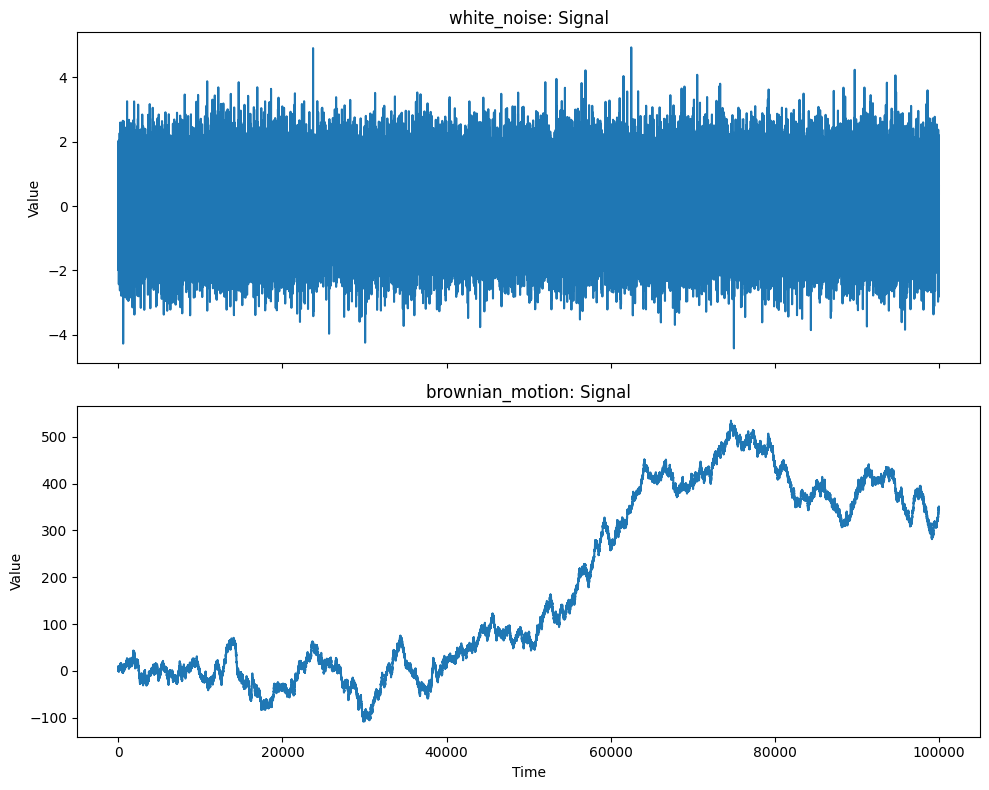

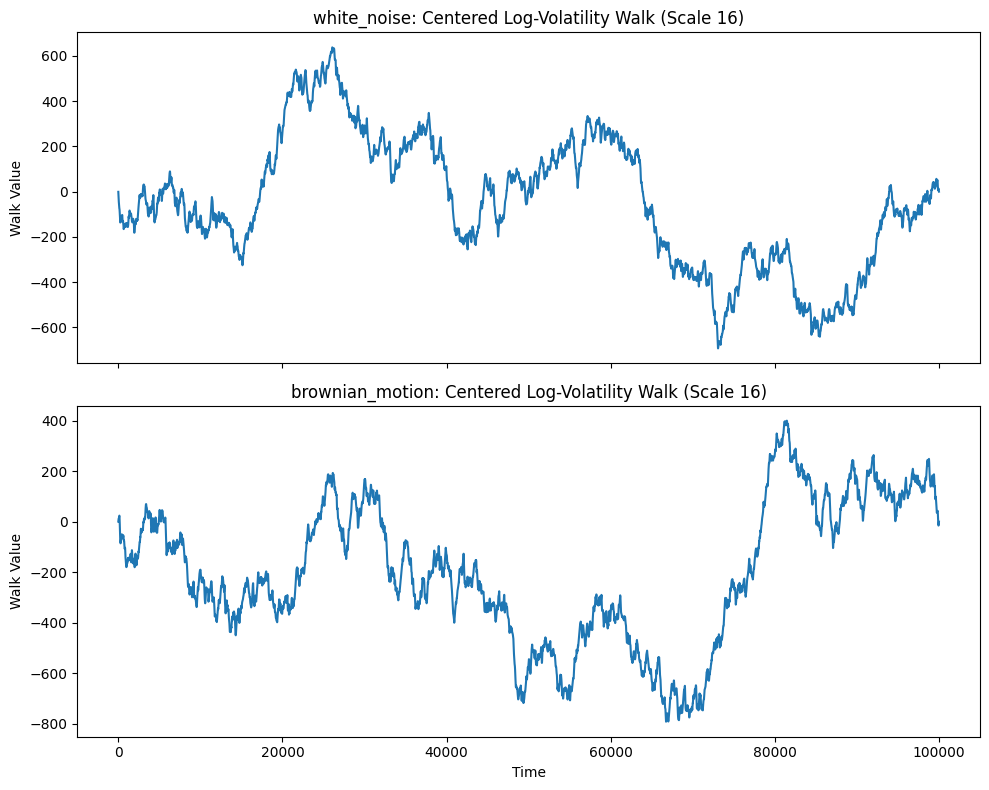

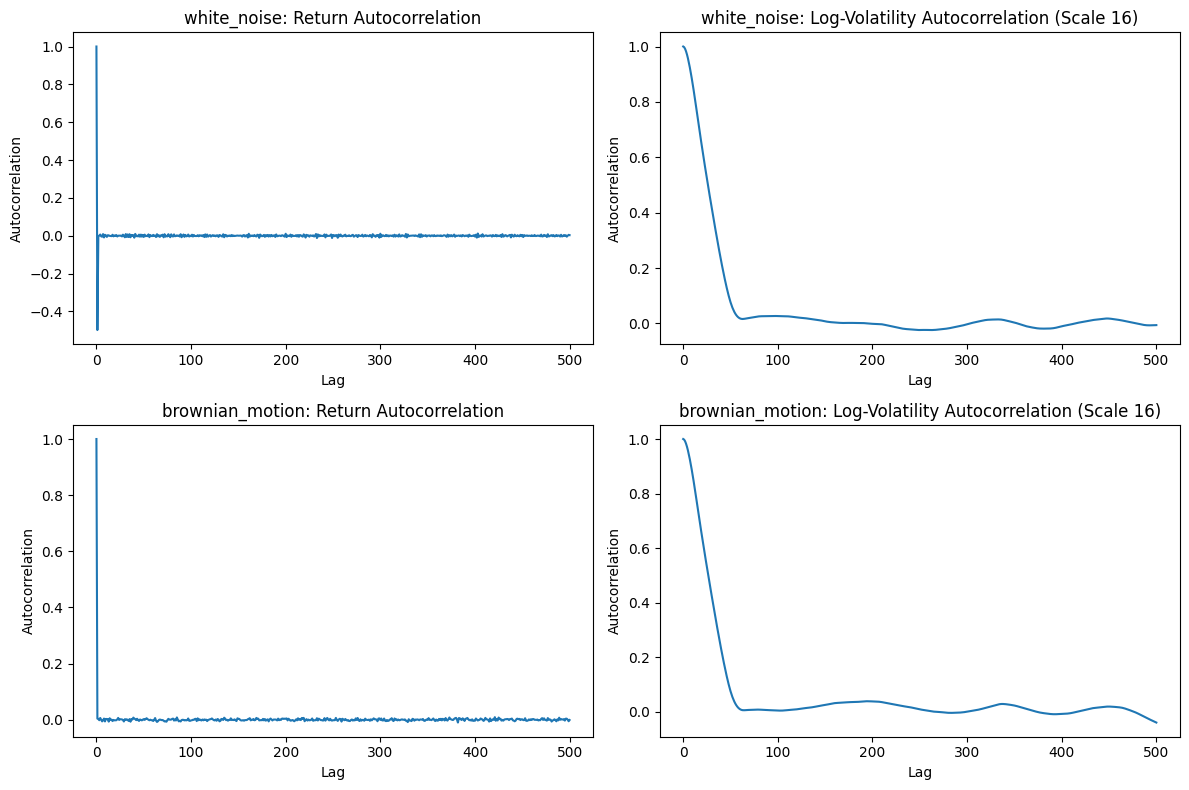

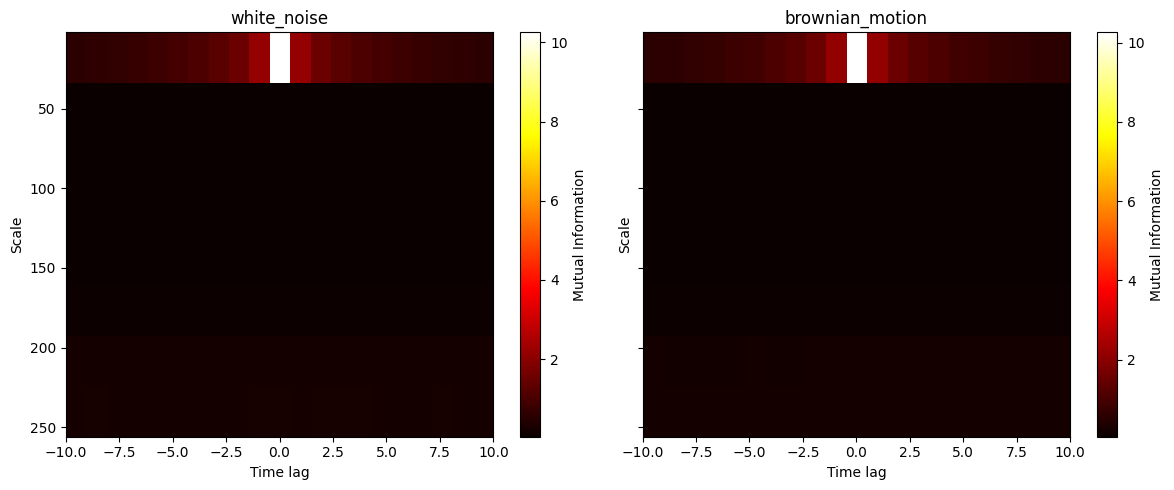

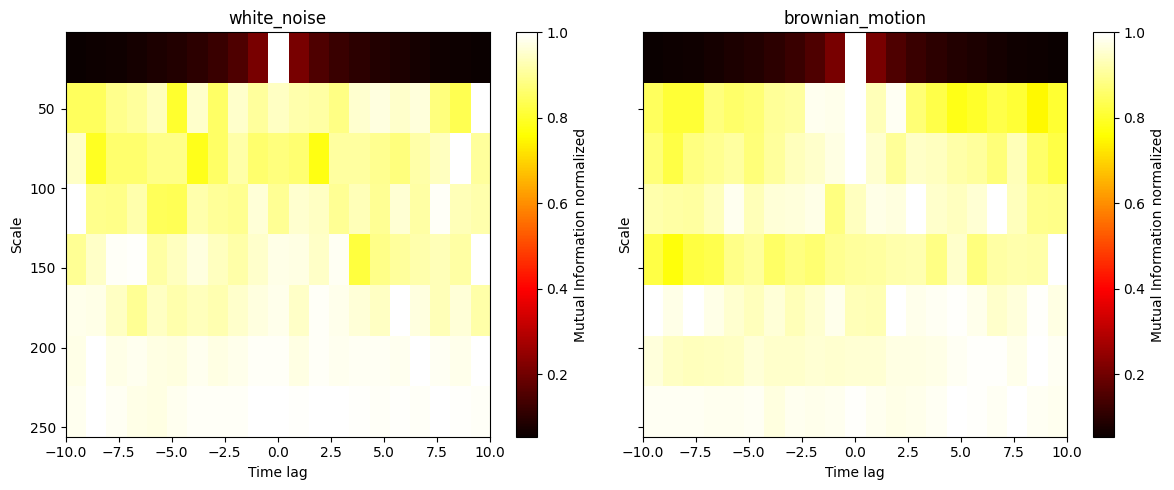

In [ ]:

if __name__ == "__main__":
    n_samples = 100_000
    signals = {
        "white_noise": white_noise(n_samples),
        "brownian_motion": brownian_motion(n_samples),
    }

    results = compare_signals(
        signals,
        wavelet="haar",
        max_level=8,
        window=50,
        ref_idx=0,
        max_time_lag=10,
        use_parallel=True,
        n_jobs=8,
    )

    for name, output in results.items():
        print(f"{name}: log_vol_series shape = {output['log_vol_series'].shape}, mi_map shape = {output['mi_map'].shape}")

    plot_signals(results)
    plot_volatility_walks(results, scale_idx=3)
    plot_autocorrelations(results, scale_idx=3, max_lag=500)
    plot_mi_maps(results, max_time_lag=10)




lognormal_cascade_0.05: log_vol_series shape = (8, 32768), mi_map shape = (8, 21)
lognormal_cascade_0.1: log_vol_series shape = (8, 32768), mi_map shape = (8, 21)
lognormal_cascade_0.5: log_vol_series shape = (8, 32768), mi_map shape = (8, 21)


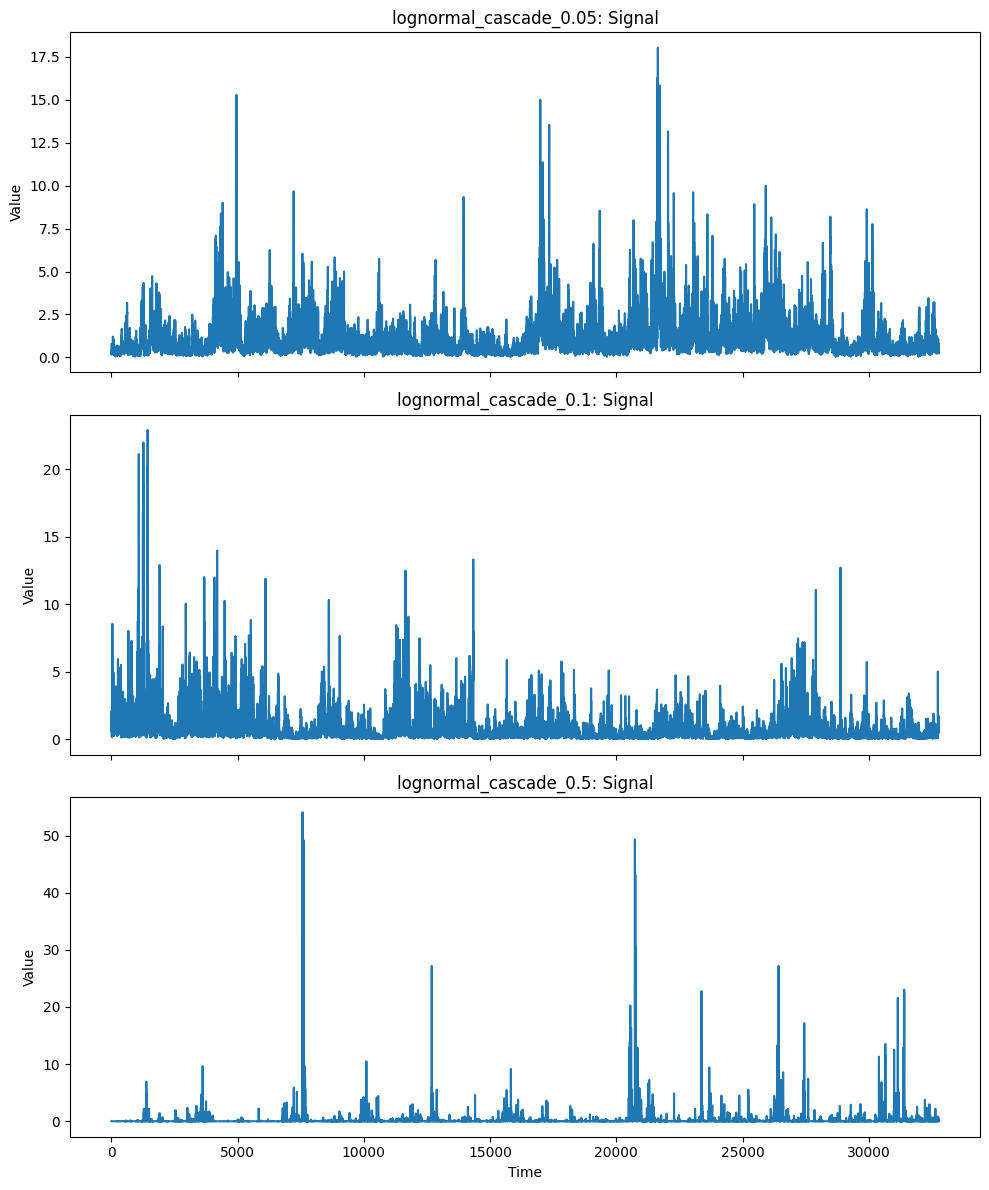

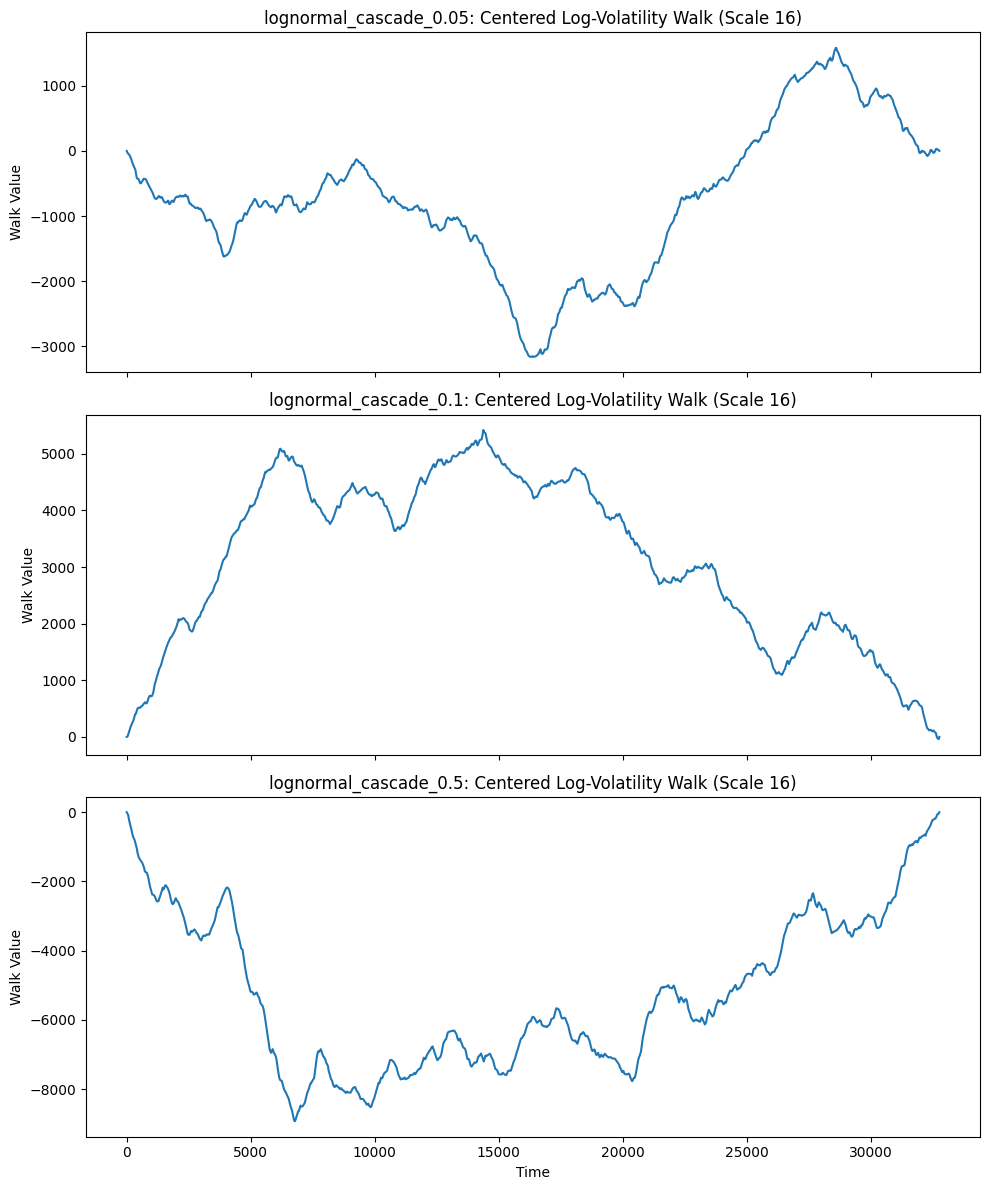

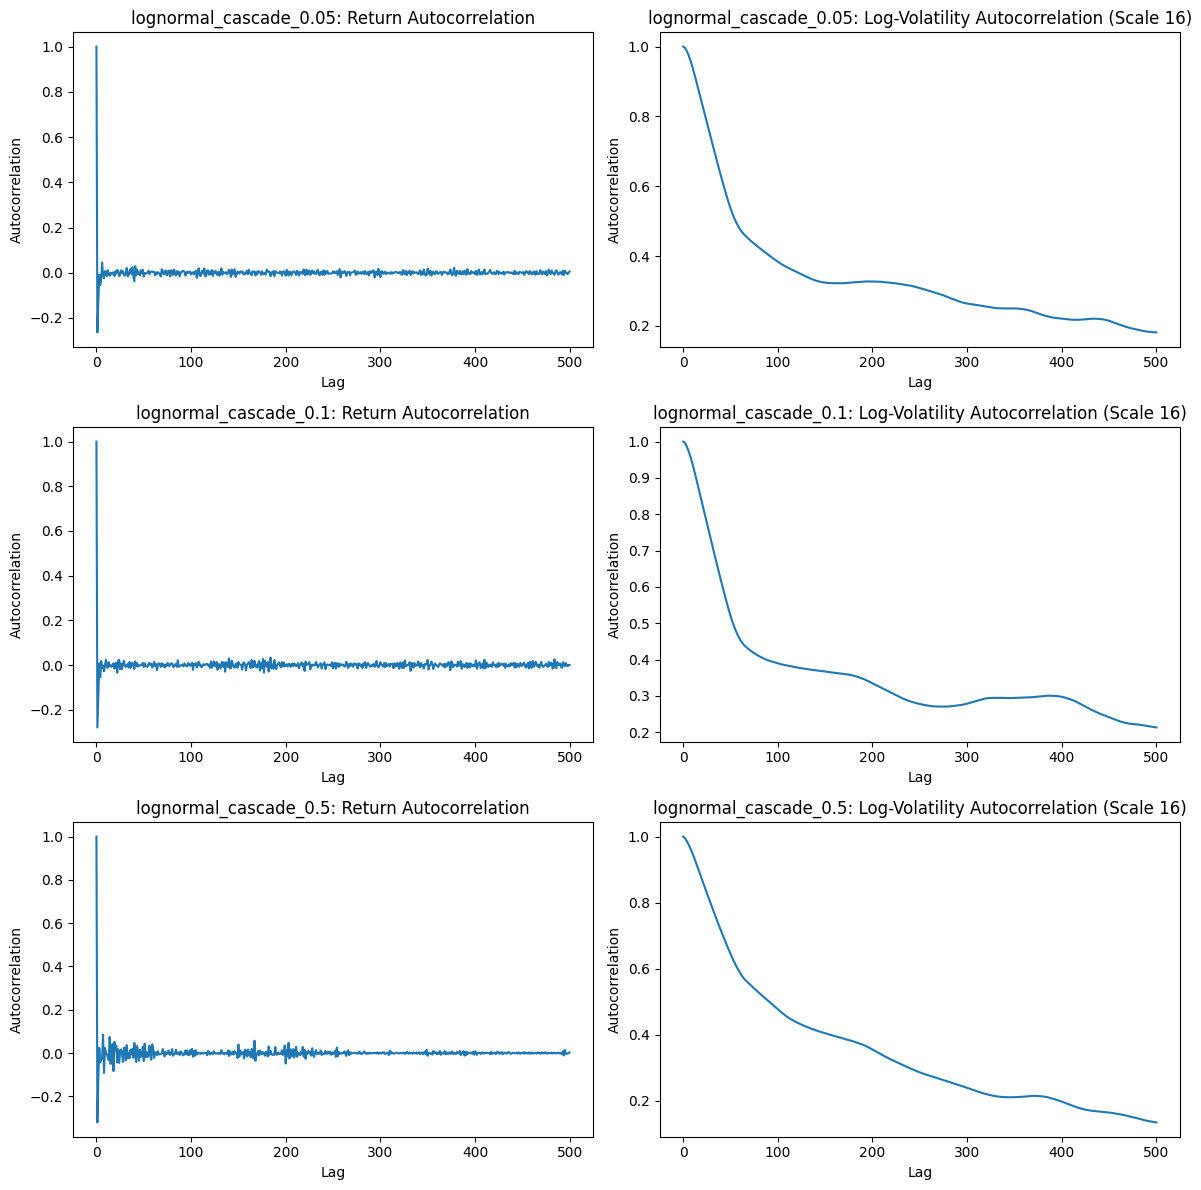

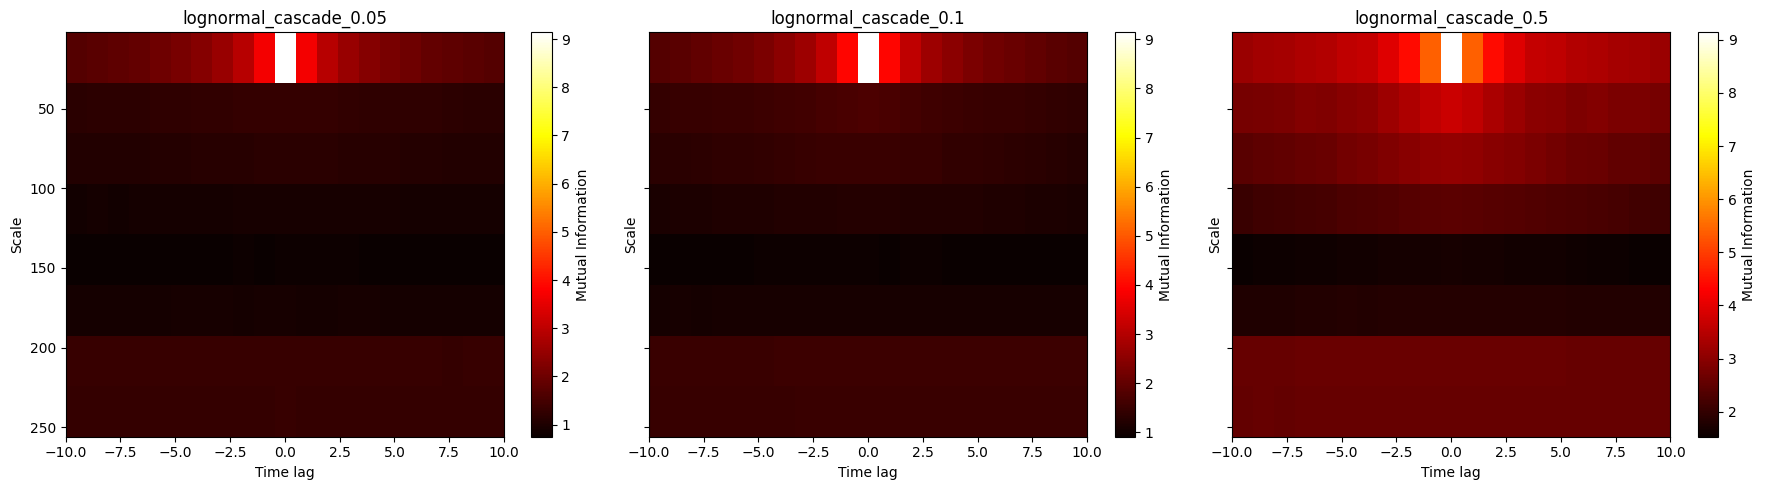

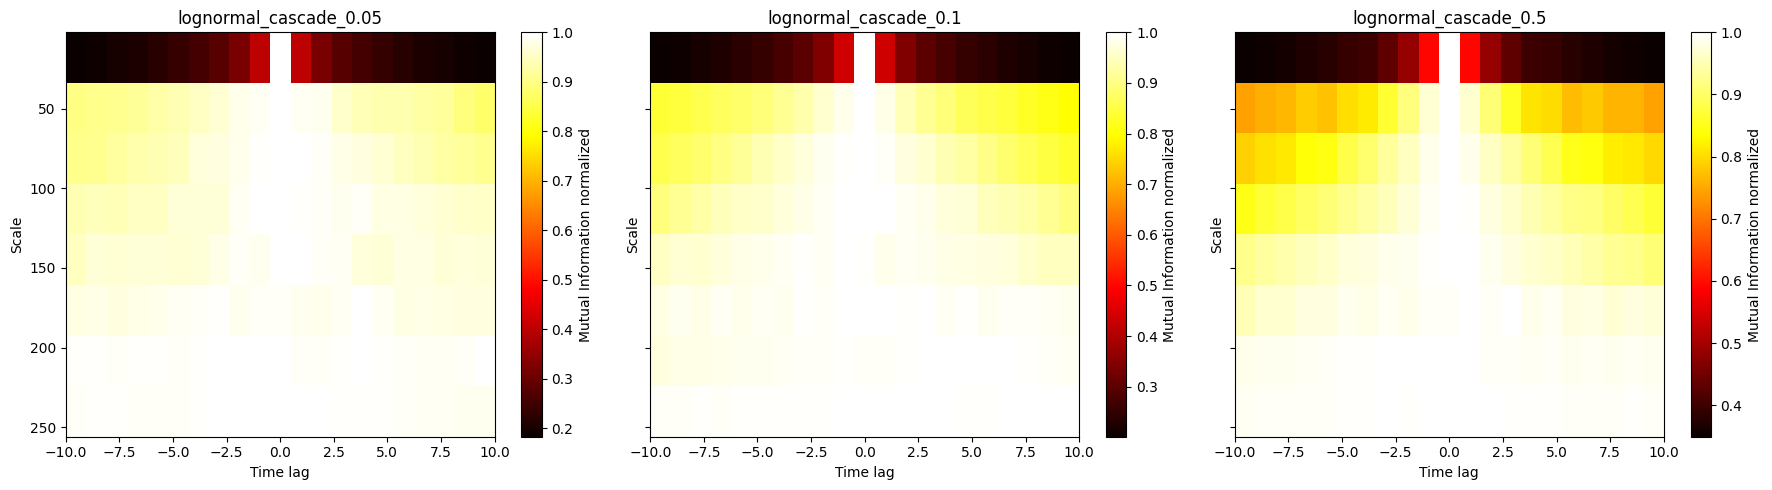

In [10]:
if __name__ == "__main__":
    n_samples = 2**15
    signals = {
        "lognormal_cascade_0.05": generate_lognormal_cascade(n_samples,0.05),
        "lognormal_cascade_0.1": generate_lognormal_cascade(n_samples,0.1),
        "lognormal_cascade_0.5": generate_lognormal_cascade(n_samples,0.5),
    }

    results = compare_signals(
        signals,
        wavelet="haar",
        max_level=8,
        window=50,
        ref_idx=0,
        max_time_lag=10,
        use_parallel=True,
        n_jobs=8,
    )

    for name, output in results.items():
        print(f"{name}: log_vol_series shape = {output['log_vol_series'].shape}, mi_map shape = {output['mi_map'].shape}")

    plot_signals(results)
    plot_volatility_walks(results, scale_idx=3)
    plot_autocorrelations(results, scale_idx=3, max_lag=500)
    plot_mi_maps(results, max_time_lag=10)

mrw_0.05: log_vol_series shape = (8, 1024), mi_map shape = (8, 21)
mrw_0.1: log_vol_series shape = (8, 1024), mi_map shape = (8, 21)
mrw_0.5: log_vol_series shape = (8, 1024), mi_map shape = (8, 21)


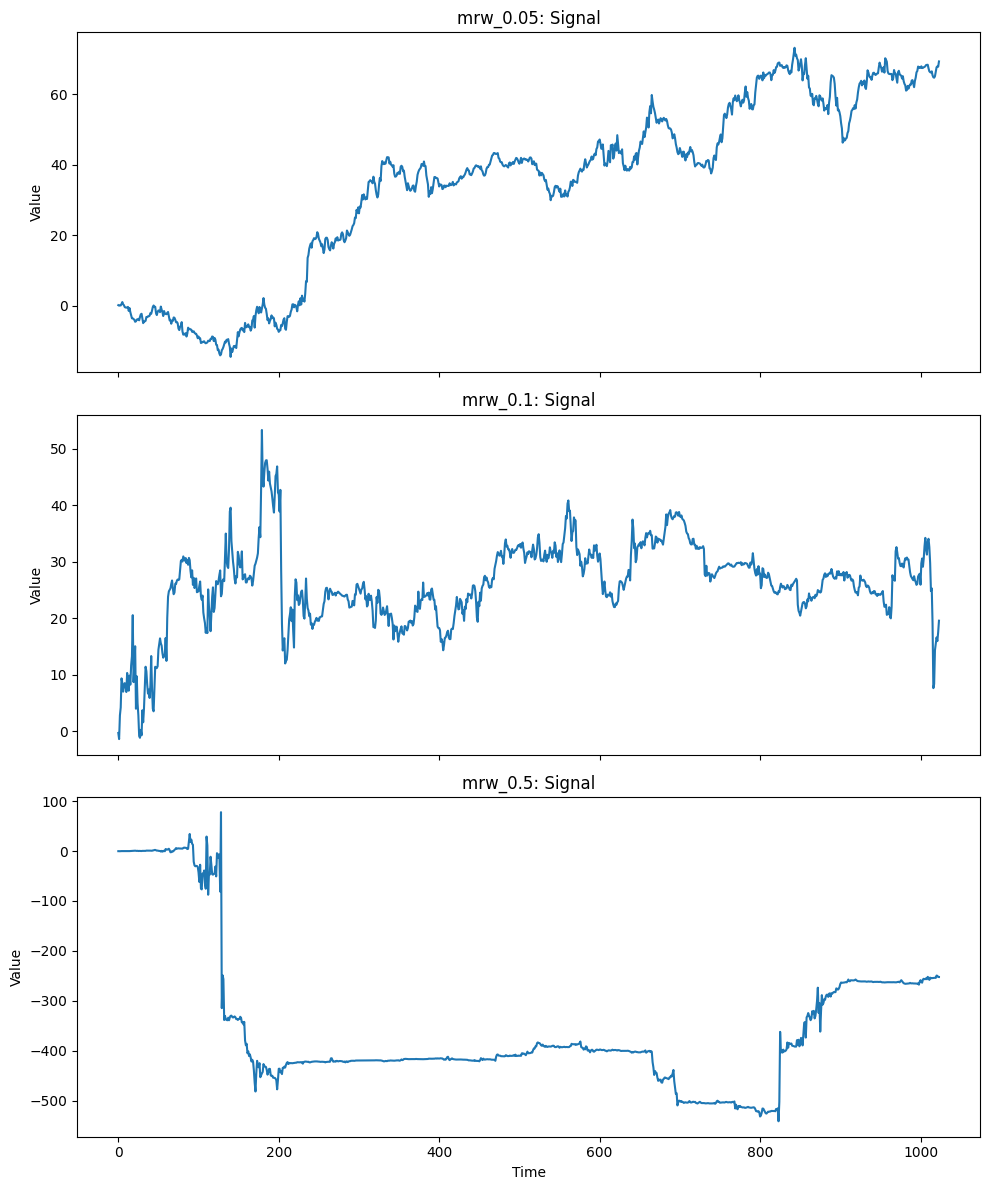

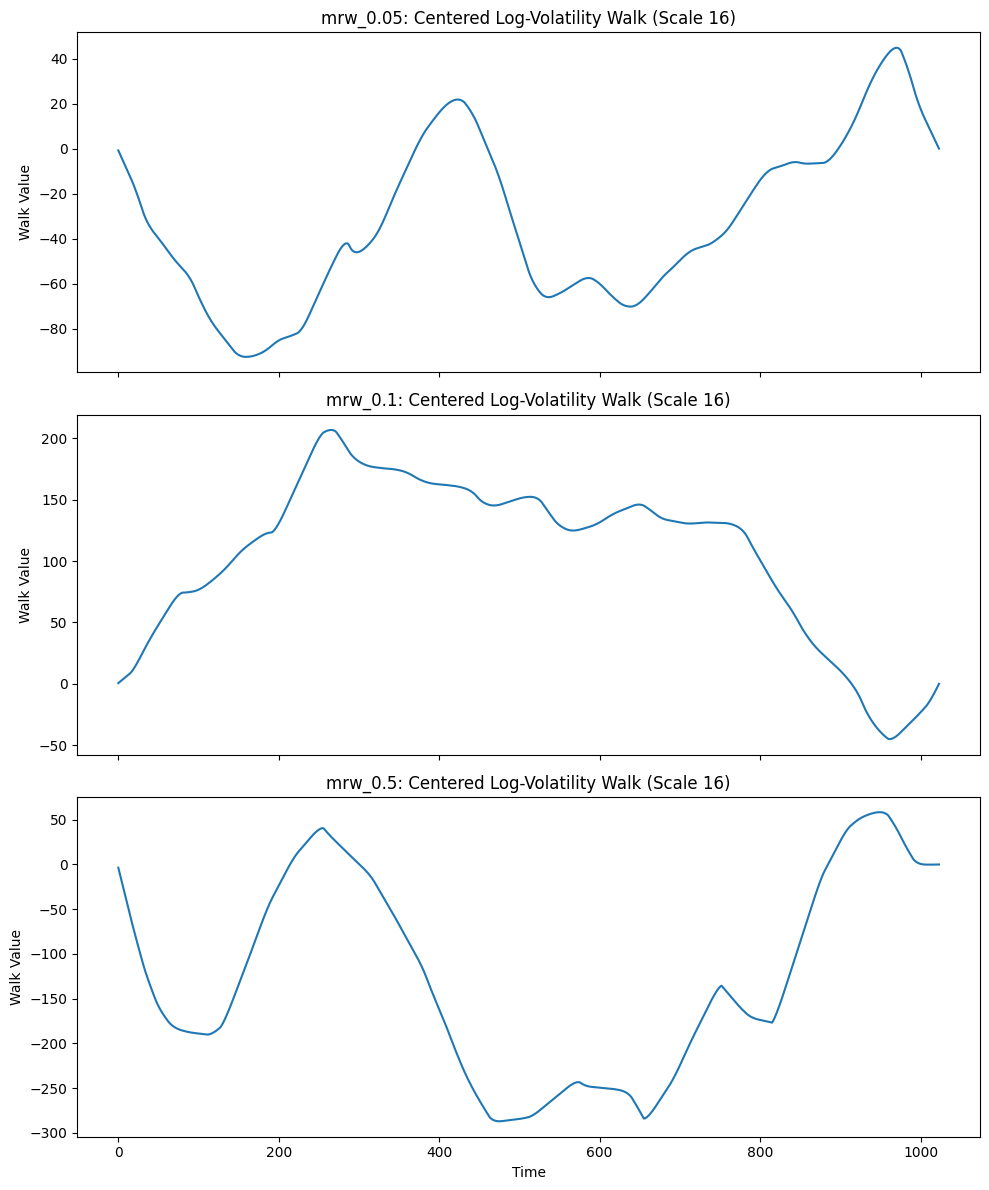

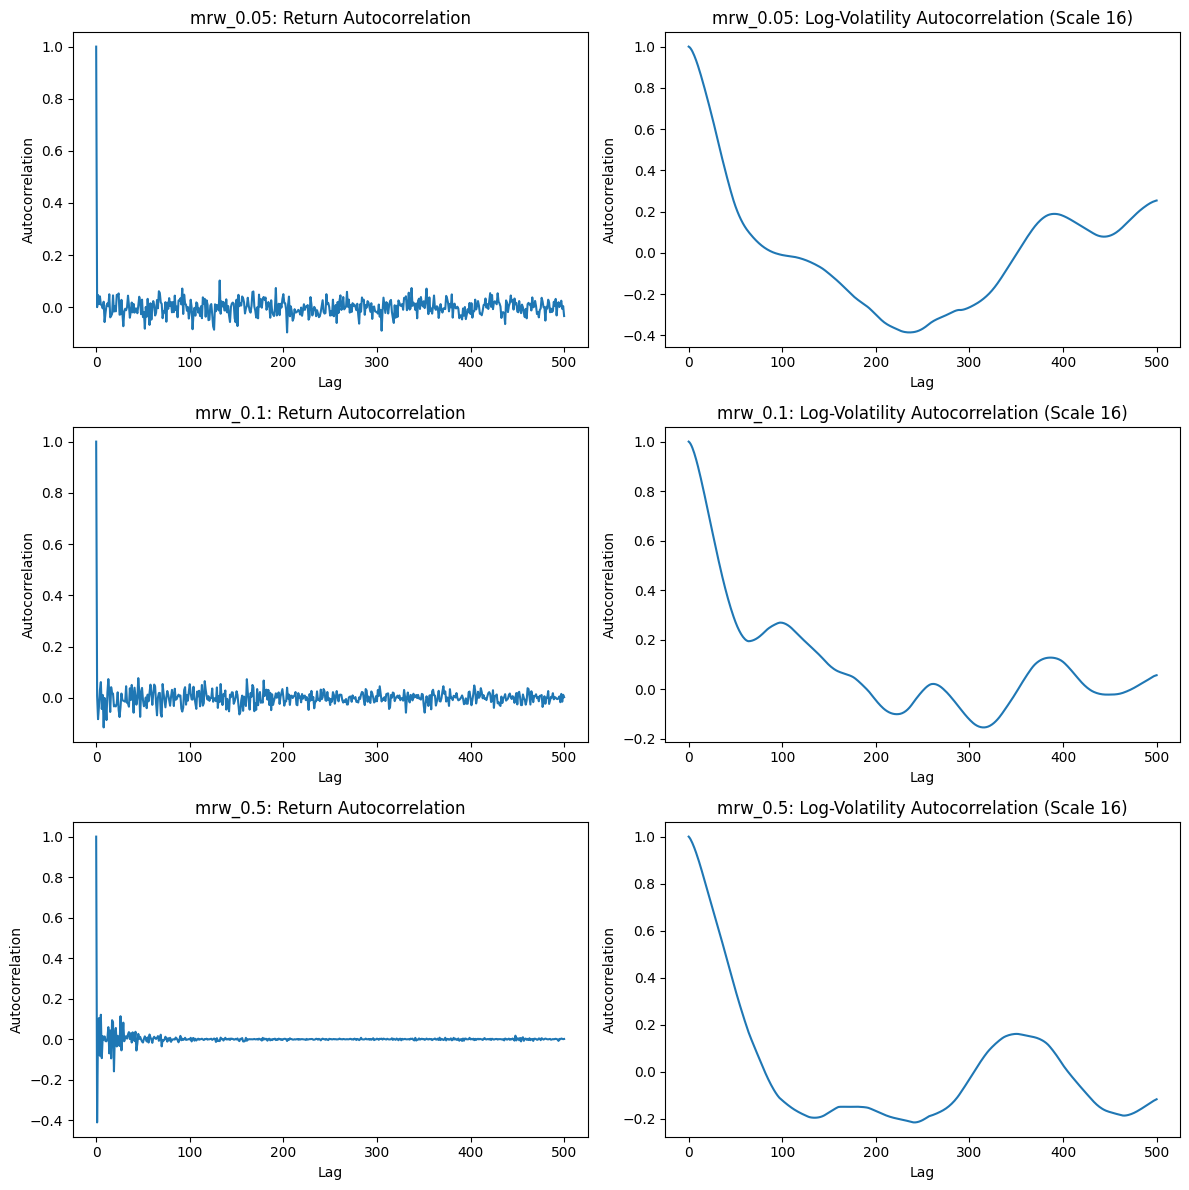

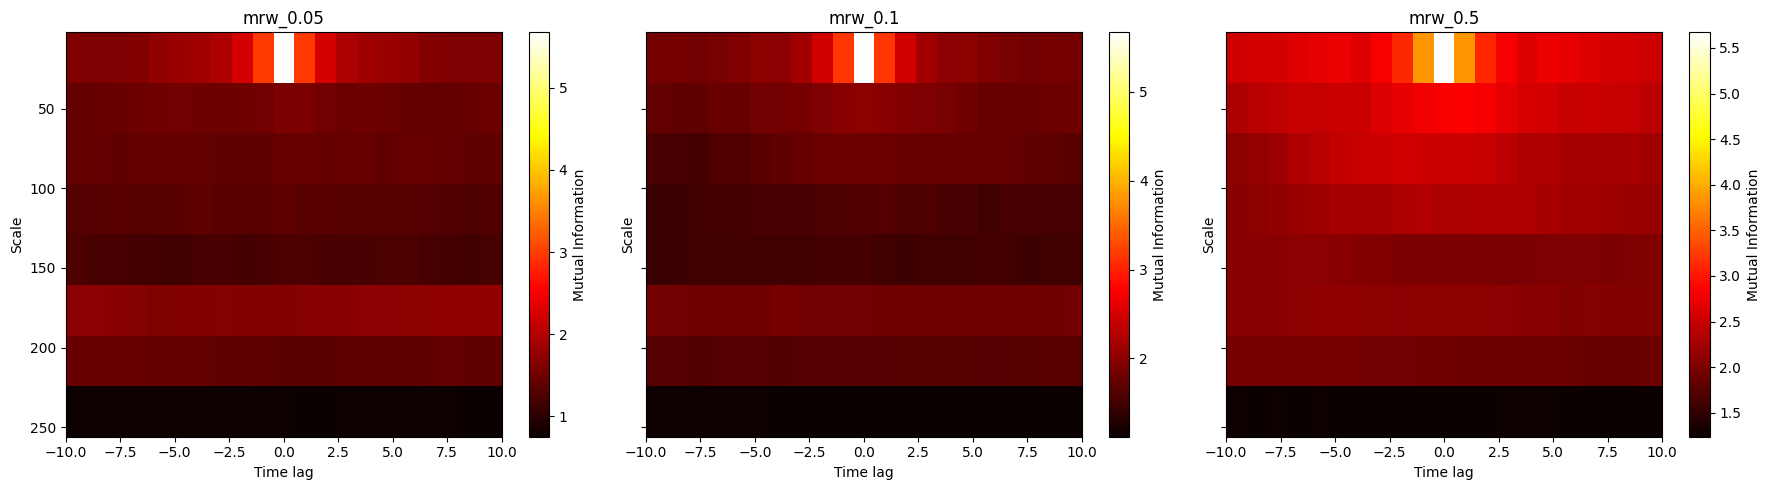

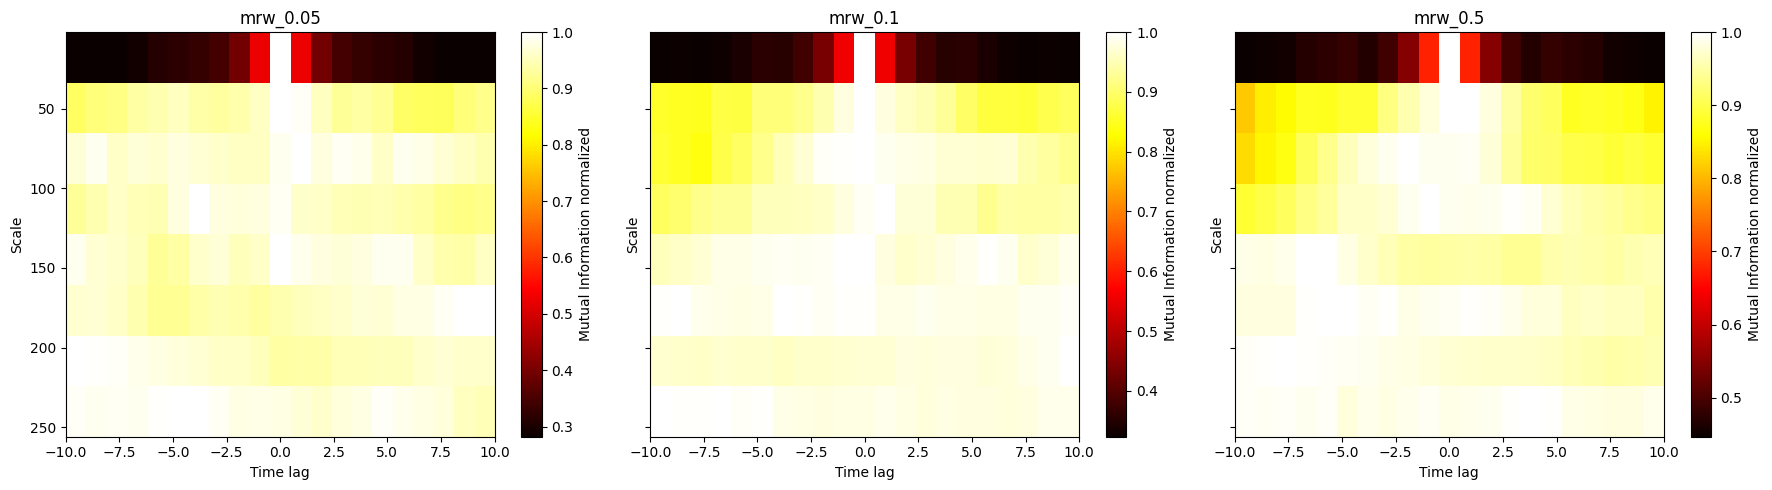

In [5]:
if __name__ == "__main__":
    n_samples = 2**10
    signals = {
        "mrw_0.05": generate_mrw(n_samples,0.05)[0],
        "mrw_0.1": generate_mrw(n_samples,0.1)[0],
        "mrw_0.5": generate_mrw(n_samples,0.5)[0],
    }

    results = compare_signals(
        signals,
        wavelet="haar",
        max_level=8,
        window=50,
        ref_idx=0,
        max_time_lag=10,
        use_parallel=True,
        n_jobs=8,
    )

    for name, output in results.items():
        print(f"{name}: log_vol_series shape = {output['log_vol_series'].shape}, mi_map shape = {output['mi_map'].shape}")

    plot_signals(results)
    plot_volatility_walks(results, scale_idx=3)
    plot_autocorrelations(results, scale_idx=3, max_lag=500)
    plot_mi_maps(results, max_time_lag=10)